# Fine-Tuning **Uncased DistilBERT** for Classification:
 
 - **Classification** of texts into categories using **AG News Dataset**.

 - The categories are:
    - **World**
    
    - **Sports**
    
    - **Business**
    
    - **Science**
    

In [ ]:
# Importing Libraries:

import numpy as np
import pandas as pd
import torch

import datasets
from datasets import load_dataset

import transformers

import evaluate

# Preprocessing:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Training:
from transformers import TrainingArguments, Trainer

# Post Training Analysis:
from transformers import pipeline

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay




## Loading AG News Dataset:


In [2]:
news_dataset = load_dataset("ag_news")
news_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [3]:
# Training Dataset and features:
news_train_dataset = news_dataset["train"]
print(news_train_dataset.features)


{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'], id=None)}


In [4]:
# World News:
news_train_dataset[492]

{'text': 'Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\\and in large numbers on Sunday to vote in a historic referendum\\that will either remove left-wing President Hugo Chavez from\\office or give him a new mandate to govern for the next two\\years.',
 'label': 0}

In [5]:
# Sports News:
news_train_dataset[1300]

{'text': "Phelps's chase of Spitz mark? It's history This was the event Michael Phelps didn't really need to compete in if his goal was to win eight golds. He probably would have had a better chance somewhere else.",
 'label': 1}

In [6]:
# Business News:
news_train_dataset[41]

{'text': "Somewhere between gleam and gloom President Bush has been saying that the US economy has ''turned the corner. quot; Democratic presidential candidate Senator John F. Kerry, in the wake of this month's poor jobs report, quipped that it was more like a U-turn.",
 'label': 2}

In [7]:
# Sci/Tech News:
news_train_dataset[100]

{'text': 'Comets, Asteroids and Planets around a Nearby Star (SPACE.com) SPACE.com - A nearby star thought to harbor comets and asteroids now appears to be home to planets, too. The presumed worlds are smaller than Jupiter and could be as tiny as Pluto, new observations suggest.',
 'label': 3}

In [ ]:
# Defining news id to label map:
news_id_to_label_map = { 0:"World", 1:"Sports", 2:"Business", 3:"Sci/Tech" }

## Preprocessing:

### Loading the tokenizer for DistilBERT:


In [9]:
# Loading tokenizer for DistilBERT: 
model_name = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


In [10]:
# Define Tokenizer wrapper function:
def tokenizer_wrapper(batch):
    return tokenizer(
        batch["text"], truncation=True, padding=True, return_tensors="pt"
    )


In [11]:
# Showing example tokenization:
tokenizer_wrapper(news_train_dataset[4:5])

{'input_ids': tensor([[  101,  3514,  7597,  2061,  2906,  2000,  2035,  1011,  2051,  2501,
          1010, 20540,  2047, 19854,  2000,  2149,  4610,  1006, 21358,  2361,
          1007, 21358,  2361,  1011,  7697,  9497,  2088,  3514,  7597,  1010,
          2327, 14353,  2636,  1998, 21366, 15882,  2015,  1010,  2556,  1037,
          2047,  3171, 19854,  4510,  2093,  2706,  2077,  1996,  2149,  4883,
          3864,  1012,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1]])}

### Tokenizing the AG News Dataset:

In [12]:
tokenized_news_datasets = news_dataset.map(tokenizer_wrapper, batched=True)
tokenized_news_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 7600
    })
})

In [13]:
# Showing example tokenization:
ip_index = 69
print(f"Sample Text:\n{tokenized_news_datasets['train']['text'][ip_index]}")
print(f"\n\nlabel_id:\n{tokenized_news_datasets['train']['label'][ip_index]}")
print(f"\n\ntokenized_ids:\n{tokenized_news_datasets['train']['input_ids'][ip_index]}")
print(f"\n\nattention_mask:\n{tokenized_news_datasets['train']['attention_mask'][ip_index]}")



Sample Text:
Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections.


label_id:
2


tokenized_ids:
[101, 3514, 7597, 2061, 2906, 2000, 2035, 1011, 2051, 2501, 1010, 20540, 2047, 19854, 2000, 2149, 4610, 1006, 21358, 2361, 1007, 21358, 2361, 1011, 7697, 9497, 2088, 3514, 7597, 1010, 2327, 14353, 2636, 1998, 21366, 15882, 2015, 1010, 2556, 1037, 2047, 3171, 19854, 4510, 2093, 2706, 2077, 1996, 2149, 4883, 3864, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Define Compute Metrics for Evaluation:

### Accuracy:


In [14]:
accuracy = evaluate.load("accuracy")
print(accuracy.description)



Accuracy is the proportion of correct predictions among the total number of cases processed. It can be computed with:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
 Where:
TP: True positive
TN: True negative
FP: False positive
FN: False negative



### F1 Score:

In [15]:
f1_score = evaluate.load("f1")
print(f1_score.description)


The F1 score is the harmonic mean of the precision and recall. It can be computed with the equation:
F1 = 2 * (precision * recall) / (precision + recall)



In [16]:
# Defining a wrapper function for compute metrics for Evaluation:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Accuracy:
    acc_result = accuracy.compute(references = labels, predictions = preds)
    acc = acc_result["accuracy"]

    # F1 Score:
    f1_result = f1_score.compute(
        references = labels, predictions = preds, average = "weighted"
    )
    f1 = f1_result["f1"]

    return {"accuracy": acc, "f1": f1}

## Training the Model for Fine-Tuning:


In [17]:
# Identifying device to train on GPU:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Loading the Uncased DistilBERT model:

In [18]:
# Count of labels since we are using Encoder model with as classification head:
count_labels = 4

# Loading the model (Uncased DistilBERT) with a classification head:
model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels = count_labels
        ).to(device)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Setting up Training Arguments and Initialising the Trainer:

In [19]:
# Setting the Training Arguments:
batch_size = 32

training_args = TrainingArguments(
    "news_classification_ep3",
    push_to_hub = False,
    num_train_epochs = 3,
    eval_strategy = "epoch",
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
)


In [20]:
# Shuffling dataset to pick 20000 examples to Train/Fine-Tune over:
shuffled_dataset = tokenized_news_datasets["train"].shuffle(seed = 69)
training_subset_data = shuffled_dataset.select(range(20000))


In [21]:
# Initialize the Trainer:
trainer = Trainer(
    model = model,
    args = training_args,
    compute_metrics = compute_metrics,
    train_dataset = training_subset_data,
    eval_dataset = tokenized_news_datasets["test"],
    tokenizer = tokenizer,
)

/tmp/ipykernel_3214805/2300149789.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### Start Training/Fine-Tuning the model:

In [22]:
# Train the model:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.322100,0.255045,0.911711,0.910830
2,0.180600,0.245378,0.925921,0.925983
3,0.114900,0.261539,0.928421,0.928449


TrainOutput(global_step=1875, training_loss=0.18041383361816407, metrics={'train_runtime': 1631.9024, 'train_samples_per_second': 36.767, 'train_steps_per_second': 1.149, 'total_flos': 5633385326752512.0, 'train_loss': 0.18041383361816407, 'epoch': 3.0})

### Saving the Fine-Tuned model:

In [ ]:
# Saving the Fine-Tuned model in './Classification_model' directory:
trainer.save_model("./Classification_model/news_classification_ep3_FT_latest")


## Post Training/Fine-Tuning Analysis: 

In [24]:
# Initialising pipeline for inferences:
pipe = pipeline(
    "text-classification",
    model="./Classification_model/news_classification_ep3_FT_latest", 
    device=device
)


# Test prediction:
pipe(
    """Manchester City cruised to victory against their rivals, with Erling Haaland scoring a hat-trick. 
    The team's dominant performance has cemented their position at the top of the league. 
    Fans are ecstatic about their chances of winning the title again."""
)

Device set to use cuda


[{'label': 'LABEL_1', 'score': 0.9950245022773743}]

In [25]:
# Example prediction:
example_text = """The Sacramento Kings fell short against the Denver Nuggets, struggling to keep up with their fast-paced offense.
                Despite a valiant effort, the Kings couldn't secure the win. The Ox and the Fox will need to regroup for their next game. """

example_prediction = pipe(example_text)
print(f"Example Prediction:\n{example_prediction}")


Example Prediction:
[{'label': 'LABEL_1', 'score': 0.9992650151252747}]


In [26]:
# Getting predictions on the entire test dataset:
test_texts = tokenized_news_datasets["test"]["text"]
model_preds = pipe(test_texts)


In [27]:
# Get the dataset reference labels and label names:
references = tokenized_news_datasets["test"]["label"]
label_names = news_train_dataset.features["label"].names


In [28]:
# Resulting predictions 5 examples:
samples = 5
for pred, ref, text in zip(model_preds[:samples], references[:samples], test_texts[:samples]):
    print(f"Text:\n{text}")
    print(f"Predicted ==> {news_id_to_label_map[int(pred["label"][-1])] } \t || \t Actual ==> {label_names[ref]}\n")


Text:
Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.
Predicted ==> Business 	 || 	 Actual ==> Business

Text:
The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket.
Predicted ==> Sci/Tech 	 || 	 Actual ==> Sci/Tech

Text:
Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.
Predicted ==> Sci/Tech 	 || 	 Actual ==> Sci/Tech

Text:
Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike 

## Post Fine-Tuning analysis

### Creating a **Confusion Matrix** for post Fine-Tuning analysis:

In [29]:
news_id_to_label_map

{0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

In [30]:
# Convert predicted labels to numerical ids:
news_label_to_id_map = {name:i for i, name in enumerate(label_names)}

# Use numerical ids so as to apply the label names:
pred_labels = [ news_id_to_label_map[int(pred["label"][-1])] for pred in model_preds]
pred_labels = [ news_label_to_id_map[elem] for elem in pred_labels]


In [31]:
# Creating confusion matrix:
confusion_matrix = evaluate.load("confusion_matrix")
cm = confusion_matrix.compute(
    references = references, predictions = pred_labels, normalize = "true"
)["confusion_matrix"]



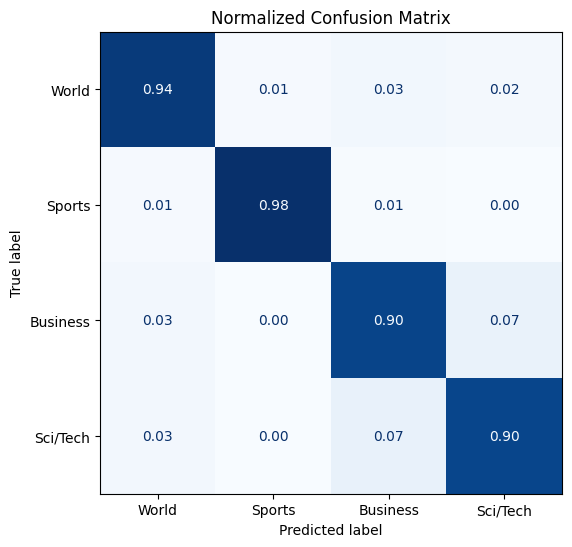

In [32]:
# Plot the normalized confusion matrix:
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = label_names)
disp.plot(cmap = "Blues", values_format = ".2f", ax = ax, colorbar = False)
plt.title("Normalized Confusion Matrix")
plt.show()

In [33]:
# Clearing cache:
torch.cuda.empty_cache()
